In [1]:
import pandas as pd

# Load dataset (replace 'data.csv' with your actual filename)
df = pd.read_csv('Data EVOL MH.csv')

# -------------------------------------------------------------
# Function to classify burnout level based on MBI subscale scores
# -------------------------------------------------------------
def classify_burnout(row):
    # Start with 0 total burnout score
    score = 0
    
    # ---- Emotional Exhaustion (EE) - mbi_ex ----
    # High (>=27) increases burnout risk more (+2 points)
    # Moderate (17–26) increases burnout risk slightly (+1 point)
    if row['mbi_ex'] >= 27:
        score += 2
    elif 17 <= row['mbi_ex'] <= 26:
        score += 1
        
    # ---- Depersonalization / Cynicism (DP) - mbi_cy ----
    # High (>=13) increases burnout risk more (+2 points)
    # Moderate (7–12) increases burnout risk slightly (+1 point)
    if row['mbi_cy'] >= 13:
        score += 2
    elif 7 <= row['mbi_cy'] <= 12:
        score += 1

    # ---- Personal Accomplishment (PA) - mbi_ea ----
    # Note: For PA, low scores mean more burnout
    # Low (<=31) = higher burnout (+2 points)
    # Moderate (32–38) = moderate burnout (+1 point)
    if row['mbi_ea'] <= 31:
        score += 2
    elif 32 <= row['mbi_ea'] <= 38:
        score += 1

    # ---- Final burnout classification ----
    # Total score decides final burnout level
    # 0–2 → Low Burnout
    # 3–4 → Moderate Burnout
    # 5–6 → High Burnout
    if score <= 2:
        return 'Low Burnout'
    elif score <= 4:
        return 'Moderate Burnout'
    else:
        return 'High Burnout'

# -------------------------------------------------------------
# Apply the function to each row in the DataFrame
# -------------------------------------------------------------
df['burnout_level'] = df.apply(classify_burnout, axis=1)

# Display selected columns to check results
print(df[['id', 'mbi_ex', 'mbi_cy', 'mbi_ea', 'burnout_level']])

# Save updated data with new burnout classification column
df.to_csv('data_with_burnout.csv', index=False)


        id  mbi_ex  mbi_cy  mbi_ea     burnout_level
0       36    19.0    11.0    20.0  Moderate Burnout
1       61    17.0    14.0    21.0      High Burnout
2       63    10.0    11.0    18.0  Moderate Burnout
3       64    30.0    23.0    16.0      High Burnout
4       69    27.0    14.0    22.0      High Burnout
...    ...     ...     ...     ...               ...
2596  2638    18.0    15.0    17.0      High Burnout
2597  5828    18.0    12.0    20.0  Moderate Burnout
2598  5830    13.0    10.0    23.0  Moderate Burnout
2599  5832    24.0    12.0    28.0  Moderate Burnout
2600  5836    10.0     5.0    29.0       Low Burnout

[2601 rows x 5 columns]


In [2]:
# -------------------------------------------------------------
# Drop the original MBI subscale columns after classification
# -------------------------------------------------------------
df = df.drop(['mbi_ex', 'mbi_cy', 'mbi_ea'], axis=1)

# Confirm columns dropped
print("Remaining columns after dropping MBI subscales:")
print(df.columns)


Remaining columns after dropping MBI subscales:
Index(['id', 'nwave', 'longipart', 'age', 'sex', 'year', 'bmi', 'physact',
       'health', 'psyt', 'cop_e', 'cop_p', 'cop_h', 'fmale', 'part', 'socsup',
       'educ_par', 'jobhours', 'cesd', 'bdi_su', 'stai', 'stress',
       'burnout_level'],
      dtype='object')


In [3]:
# -------------------------------------------------------------
# STEP 1.1 - Import required libraries
# -------------------------------------------------------------
import pandas as pd
import numpy as np



# Show first few rows to confirm load
df.head()


,id,nwave,longipart,age,sex,year,bmi,physact,health,psyt,...,fmale,part,socsup,educ_par,jobhours,cesd,bdi_su,stai,stress,burnout_level
0,36,1,1,21.0,2,2,24.158817,0.0,2.0,1.0,...,0,1.0,8.5,2,0.0,19.0,0.0,48.0,6.0,Moderate Burnout
1,61,1,1,20.0,2,1,27.440599,2.0,3.0,1.0,...,0,0.0,9.0,0,4.0,28.0,1.0,51.0,6.0,High Burnout
2,63,1,1,26.0,1,6,23.849777,3.0,4.0,0.0,...,1,1.0,7.0,2,10.0,1.0,0.0,23.0,1.0,Moderate Burnout
3,64,1,1,19.0,2,1,21.877550,3.0,3.0,0.0,...,0,1.0,8.0,1,0.0,54.0,2.0,72.0,8.0,High Burnout
4,69,1,1,22.0,2,3,20.077335,0.0,4.0,0.0,...,0,1.0,10.0,2,0.0,24.0,0.0,55.0,5.0,High Burnout


In [4]:
# -------------------------------------------------------------
# STEP 1.2 - Check general information about the dataset
# -------------------------------------------------------------
print("Dataset shape:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nData types:\n")
print(df.dtypes)

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset shape: (2601, 23)

Column names:
 Index(['id', 'nwave', 'longipart', 'age', 'sex', 'year', 'bmi', 'physact',
       'health', 'psyt', 'cop_e', 'cop_p', 'cop_h', 'fmale', 'part', 'socsup',
       'educ_par', 'jobhours', 'cesd', 'bdi_su', 'stai', 'stress',
       'burnout_level'],
      dtype='object')

Data types:

id                 int64
nwave              int64
longipart          int64
age              float64
sex                int64
year               int64
bmi              float64
physact          float64
health           float64
psyt             float64
cop_e            float64
cop_p            float64
cop_h            float64
fmale              int64
part             float64
socsup           float64
educ_par           int64
jobhours         float64
cesd             float64
bdi_su           float64
stai             float64
stress           float64
burnout_level     object
dtype: object

Missing values per column:
id                0
nwave             0
longipart         0

In [5]:
# -------------------------------------------------------------
# STEP 1.3 - Handle missing values
# -------------------------------------------------------------
# Example: Replace numeric NaN values with column mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Example: Replace categorical NaN values with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(" Missing values handled successfully")


 Missing values handled successfully


In [6]:
print(" Missing values before handling:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

 Missing values before handling:

id               0
nwave            0
longipart        0
age              0
sex              0
year             0
bmi              0
physact          0
health           0
psyt             0
cop_e            0
cop_p            0
cop_h            0
fmale            0
part             0
socsup           0
educ_par         0
jobhours         0
cesd             0
bdi_su           0
stai             0
stress           0
burnout_level    0
dtype: int64

Total missing values: 0


In [7]:
# -------------------------------------------------------------
# STEP 1.4 - Encode the target variable
# -------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['burnout_level_encoded'] = le.fit_transform(df['burnout_level'])

# Map encoding for reference
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding mapping:", label_mapping)

# Drop original burnout_level if preferred
# (optional - we keep both for now)


Label encoding mapping: {'High Burnout': np.int64(0), 'Low Burnout': np.int64(1), 'Moderate Burnout': np.int64(2)}


In [8]:
# -------------------------------------------------------------
# STEP 1.5 - Separate features (X) and target (y)
# -------------------------------------------------------------
# Target variable
y = df['burnout_level_encoded']

# Features - drop columns not used for prediction
X = df.drop(['id', 'burnout_level', 'burnout_level_encoded'], axis=1, errors='ignore')

print(" Feature set and target separated successfully")
print("Feature shape:", X.shape)


 Feature set and target separated successfully
Feature shape: (2601, 21)


In [9]:
# -------------------------------------------------------------
# STEP 1.6 - Identify categorical and numerical features
# -------------------------------------------------------------
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", cat_features)
print("Numeric columns:", num_features)


Categorical columns: []
Numeric columns: ['nwave', 'longipart', 'age', 'sex', 'year', 'bmi', 'physact', 'health', 'psyt', 'cop_e', 'cop_p', 'cop_h', 'fmale', 'part', 'socsup', 'educ_par', 'jobhours', 'cesd', 'bdi_su', 'stai', 'stress']


In [10]:
# -------------------------------------------------------------
# STEP 1.7 - Encode categorical columns (if any)
# -------------------------------------------------------------
X = pd.get_dummies(X, columns=cat_features, drop_first=True)

print(" Categorical features encoded successfully")
print("Updated feature shape:", X.shape)


 Categorical features encoded successfully
Updated feature shape: (2601, 21)


In [11]:
# -------------------------------------------------------------
# STEP 1.8 - Scale numeric columns
# -------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print(" Numeric features scaled successfully")


 Numeric features scaled successfully


In [12]:
# -------------------------------------------------------------
# STEP 1.9 - Verify final dataset before model training
# -------------------------------------------------------------
print(" Final prepared dataset summary:")
print(X.info())
print("\nTarget distribution:\n", y.value_counts())


 Final prepared dataset summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601 entries, 0 to 2600
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   nwave      2601 non-null   float64
 1   longipart  2601 non-null   float64
 2   age        2601 non-null   float64
 3   sex        2601 non-null   float64
 4   year       2601 non-null   float64
 5   bmi        2601 non-null   float64
 6   physact    2601 non-null   float64
 7   health     2601 non-null   float64
 8   psyt       2601 non-null   float64
 9   cop_e      2601 non-null   float64
 10  cop_p      2601 non-null   float64
 11  cop_h      2601 non-null   float64
 12  fmale      2601 non-null   float64
 13  part       2601 non-null   float64
 14  socsup     2601 non-null   float64
 15  educ_par   2601 non-null   float64
 16  jobhours   2601 non-null   float64
 17  cesd       2601 non-null   float64
 18  bdi_su     2601 non-null   float64
 19  stai       2601

 Correlation of features with burnout_level_encoded:

burnout_level_encoded    1.000000
health                   0.131977
socsup                   0.094512
cop_h                    0.045617
cop_p                    0.028335
physact                  0.028202
bmi                      0.026537
nwave                    0.016562
fmale                    0.013618
id                       0.007148
part                     0.005819
age                      0.005496
longipart                0.003416
year                    -0.006789
sex                     -0.019262
educ_par                -0.021268
jobhours                -0.024557
psyt                    -0.100118
cop_e                   -0.103975
stai                    -0.120157
stress                  -0.141779
cesd                    -0.238587
bdi_su                  -0.256245
Name: burnout_level_encoded, dtype: float64


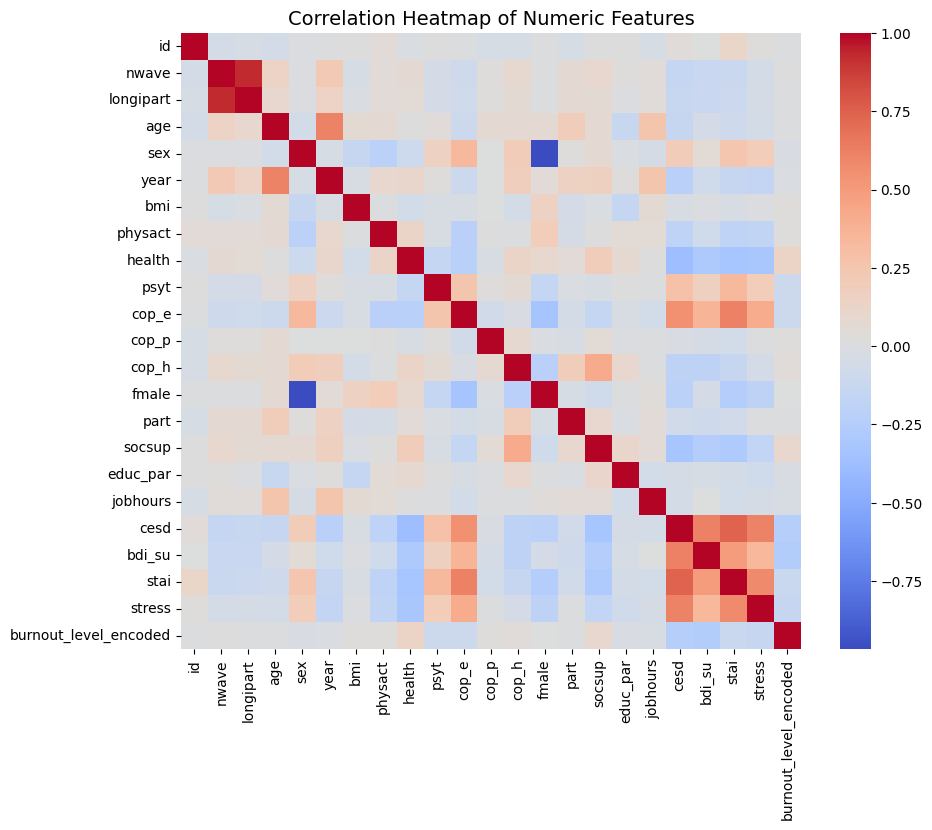

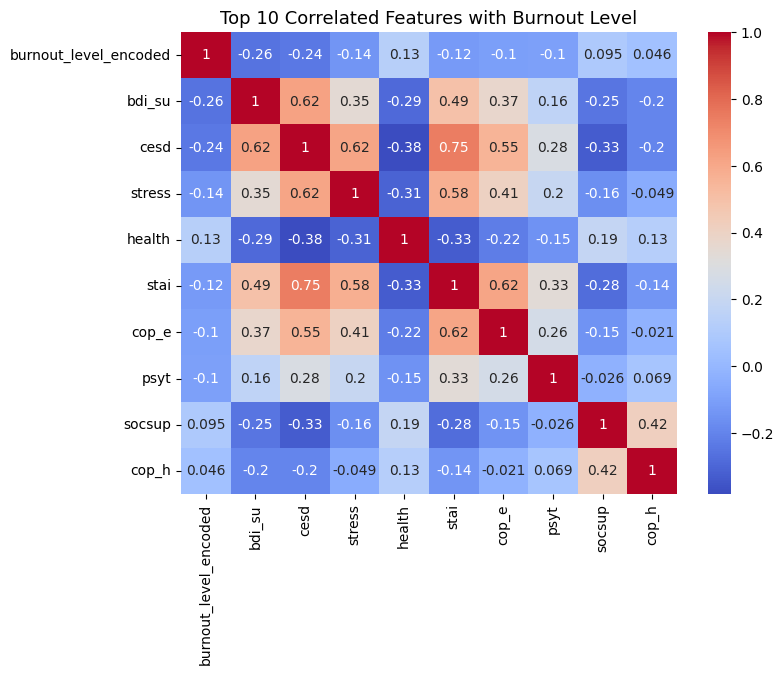

In [13]:
# -------------------------------------------------------------
# STEP 1.5 - Correlation Analysis
# -------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numeric features
corr_matrix = df.corr(numeric_only=True)

# Show top correlated features with burnout_level_encoded
target_corr = corr_matrix['burnout_level_encoded'].sort_values(ascending=False)

print(" Correlation of features with burnout_level_encoded:\n")
print(target_corr)

# Visualize correlation heatmap (top 10 features for clarity)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.show()

# Optional: Focused heatmap on top correlated variables with target
top_features = target_corr.abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features].corr(), cmap='coolwarm', annot=True)
plt.title('Top 10 Correlated Features with Burnout Level', fontsize=13)
plt.show()


In [14]:
print(X)

         nwave  longipart       age       sex      year       bmi   physact  \
0    -1.203137  -0.905106 -0.407318  0.634475 -0.743773  0.823440 -1.223081   
1    -1.203137  -0.905106 -0.726334  0.634475 -1.322981  1.940206 -0.468315   
2    -1.203137  -0.905106  1.187764 -1.454473  1.573058  0.718276 -0.090932   
3    -1.203137  -0.905106 -1.045351  0.634475 -1.322981  0.047142 -0.090932   
4    -1.203137  -0.905106 -0.088301  0.634475 -0.164565 -0.565458 -1.223081   
...        ...        ...       ...       ...       ...       ...       ...   
2596  1.156862   1.297493 -1.045351  0.634475 -0.743773 -0.525221  0.663834   
2597  1.156862   1.297493 -0.726334  0.634475 -0.164565 -0.606310  1.795982   
2598 -1.203137  -0.868998 -0.726334 -1.454473 -0.743773  0.059403  2.173365   
2599 -1.203137  -0.868998 -1.364367  0.634475 -1.322981 -0.766358 -0.090932   
2600 -1.203137  -0.868998 -0.088301  0.634475 -1.322981  0.333970 -1.223081   

        health      psyt     cop_e  ...     cop_h  

In [15]:
# -------------------------------------------------------------
# STEP 2.1 - Basic statistical overview of numerical features
# -------------------------------------------------------------
print(" Basic statistics of all numeric columns:\n")
display(df.describe())


 Basic statistics of all numeric columns:



,id,nwave,longipart,age,sex,year,bmi,physact,health,psyt,...,fmale,part,socsup,educ_par,jobhours,cesd,bdi_su,stai,stress,burnout_level_encoded
count,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,...,2601.00000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000
mean,2984.692810,2.019608,51.133026,22.276793,1.696271,3.284121,21.739017,3.240955,3.786374,0.239030,...,0.31411,0.538284,8.075599,1.286428,3.027703,18.264297,0.655719,44.240046,5.397371,1.402922
std,1692.245827,0.847621,55.399771,3.135238,0.478802,1.726828,2.939212,2.650338,0.979096,0.426327,...,0.46425,0.498436,1.912607,0.839325,6.611179,11.176026,1.022863,11.861929,2.173220,0.779482
min,2.000000,1.000000,1.000000,17.000000,1.000000,1.000000,15.426997,0.000000,1.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.000000,0.000000
25%,1515.000000,1.000000,3.000000,20.000000,1.000000,2.000000,19.723183,1.000000,3.000000,0.000000,...,0.00000,0.000000,7.000000,1.000000,0.000000,10.000000,0.000000,36.000000,3.000000,1.000000
50%,3016.000000,2.000000,23.000000,22.000000,2.000000,3.000000,21.303949,3.000000,4.000000,0.000000,...,0.00000,1.000000,8.500000,2.000000,0.000000,16.000000,0.000000,44.000000,6.000000,2.000000
75%,4451.000000,3.000000,123.000000,24.000000,2.000000,5.000000,23.148148,5.000000,4.000000,0.000000,...,1.00000,1.000000,9.500000,2.000000,4.000000,25.000000,1.000000,53.000000,7.000000,2.000000
max,5836.000000,3.000000,123.000000,51.000000,3.000000,6.000000,41.665058,21.000000,5.000000,1.000000,...,1.00000,1.000000,10.000000,2.000000,50.000000,58.000000,6.000000,80.000000,10.000000,2.000000


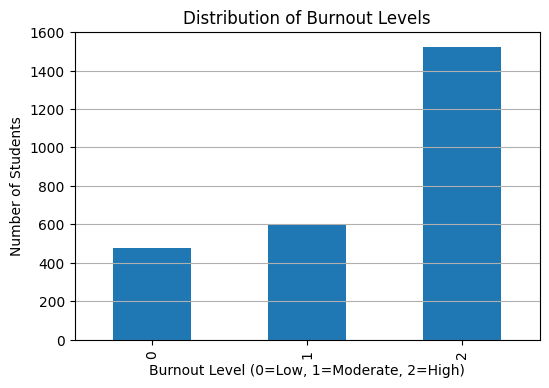

In [16]:
# -------------------------------------------------------------
# STEP 2.2 - Target variable distribution visualization
# -------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
y.value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Burnout Levels")
plt.xlabel("Burnout Level (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Number of Students")
plt.grid(axis='y')
plt.show()


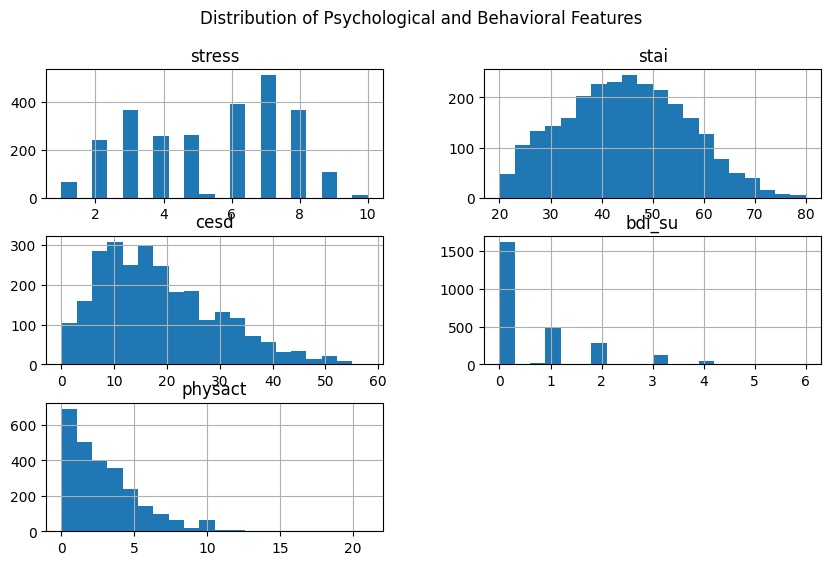

In [17]:
# -------------------------------------------------------------
# STEP 2.3 - Distribution of selected important features
# -------------------------------------------------------------
selected_features = ['stress', 'stai', 'cesd', 'bdi_su', 'physact']

df[selected_features].hist(figsize=(10,6), bins=20)
plt.suptitle("Distribution of Psychological and Behavioral Features")
plt.show()


In [18]:
# # -------------------------------------------------------------
# # STEP 2.4 - Correlation matrix and heatmap
# # -------------------------------------------------------------
# import numpy as np

# corr_matrix = X.corr()
# plt.figure(figsize=(14,10))
# plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
# plt.colorbar(label='Correlation')
# plt.title("Feature Correlation Heatmap")
# plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
# plt.yticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns)
# plt.show()


In [19]:
# -------------------------------------------------------------
# STEP 2.5 - Correlation of each feature with burnout level
# -------------------------------------------------------------
corr_with_target = df.corr(numeric_only=True)['burnout_level_encoded'].sort_values(ascending=False)
print(" Correlation of each numeric feature with target:\n")
print(corr_with_target)


 Correlation of each numeric feature with target:

burnout_level_encoded    1.000000
health                   0.131977
socsup                   0.094512
cop_h                    0.045617
cop_p                    0.028335
physact                  0.028202
bmi                      0.026537
nwave                    0.016562
fmale                    0.013618
id                       0.007148
part                     0.005819
age                      0.005496
longipart                0.003416
year                    -0.006789
sex                     -0.019262
educ_par                -0.021268
jobhours                -0.024557
psyt                    -0.100118
cop_e                   -0.103975
stai                    -0.120157
stress                  -0.141779
cesd                    -0.238587
bdi_su                  -0.256245
Name: burnout_level_encoded, dtype: float64


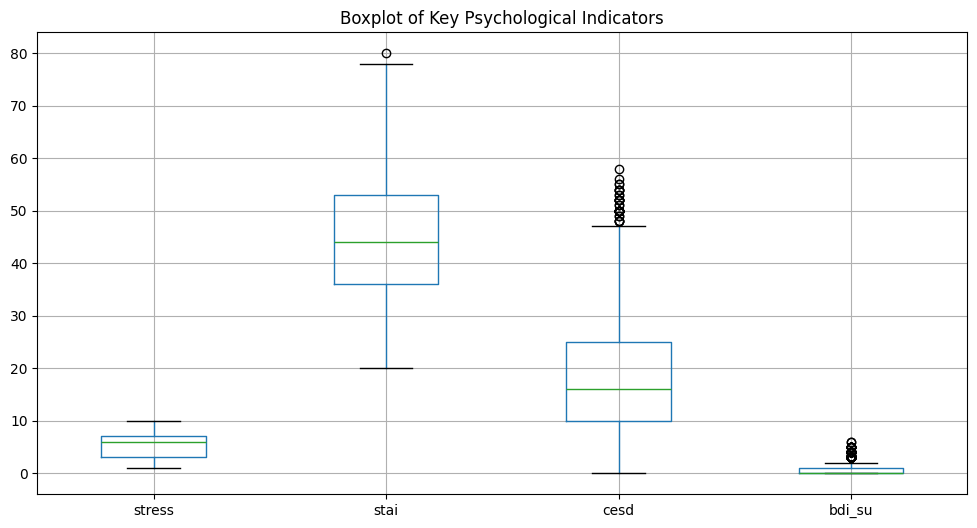

In [20]:
# -------------------------------------------------------------
# STEP 2.6 - Boxplots for outlier inspection
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
df[['stress', 'stai', 'cesd', 'bdi_su','burnout_level']].boxplot()
plt.title("Boxplot of Key Psychological Indicators")
plt.show()


 Burnout class distribution BEFORE balancing:

burnout_level_encoded
2    1525
1     599
0     477
Name: count, dtype: int64


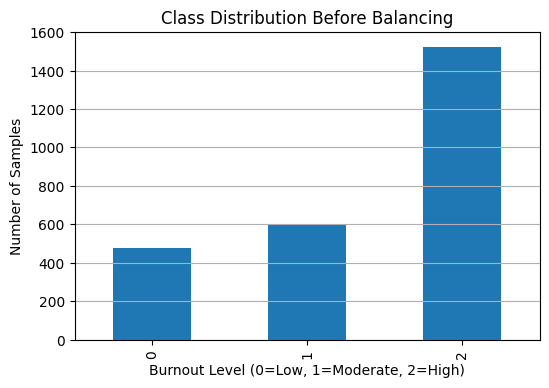

In [21]:
# -------------------------------------------------------------
# STEP 3.2 - Check class imbalance before balancing
# -------------------------------------------------------------
print(" Burnout class distribution BEFORE balancing:\n")
print(y.value_counts())

plt.figure(figsize=(6,4))
y.value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Burnout Level (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.show()



In [22]:
%pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Class balancing completed using SMOTE.

Class distribution AFTER balancing:
 burnout_level_encoded
2    1525
0    1525
1    1525
Name: count, dtype: int64


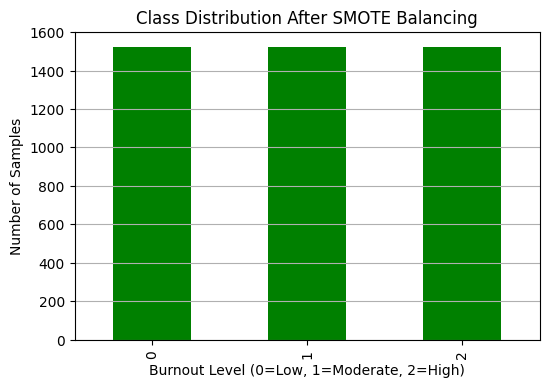

In [23]:
# -------------------------------------------------------------
# STEP 3.3 - Balance the dataset using SMOTE
# -------------------------------------------------------------
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("✅ Class balancing completed using SMOTE.")
print("\nClass distribution AFTER balancing:\n", y_resampled.value_counts())

# Visualize new balanced distribution
plt.figure(figsize=(6,4))
y_resampled.value_counts().sort_index().plot(kind='bar', color='green')
plt.title("Class Distribution After SMOTE Balancing")
plt.xlabel("Burnout Level (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.show()


In [24]:
# -------------------------------------------------------------
# STEP 3.4 - Train-test split (stratified)
# -------------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

print(" Data split into training and testing sets successfully.")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


 Data split into training and testing sets successfully.
Training set size: 3660
Testing set size: 915


In [25]:
# -------------------------------------------------------------
# STEP 3.5 - Scale numeric features
# -------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)


 Feature scaling completed successfully.
Scaled training data shape: (3660, 21)


In [26]:
# -------------------------------------------------------------
# STEP 3.6 - Verify final data shapes and consistency
# -------------------------------------------------------------
print("Final Data Summary:\n")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"y_train:        {y_train.shape}")
print(f"y_test:         {y_test.shape}")

print("\nTarget value counts in training set:\n", y_train.value_counts())
print("\nTarget value counts in testing set:\n", y_test.value_counts())


Final Data Summary:

X_train_scaled: (3660, 21)
X_test_scaled:  (915, 21)
y_train:        (3660,)
y_test:         (915,)

Target value counts in training set:
 burnout_level_encoded
0    1220
2    1220
1    1220
Name: count, dtype: int64

Target value counts in testing set:
 burnout_level_encoded
0    305
2    305
1    305
Name: count, dtype: int64


In [27]:
# -------------------------------------------------------------
# STEP 4 - Feature Selection / Dimensionality Reduction
# -------------------------------------------------------------
# In this step, we keep *all features* for the initial model build.
# Later, you can uncomment any of the drop sections below
# to remove less-important or highly correlated features.

# -------------------------------------------------------------
# 4.1 Keep all features (current default)
# -------------------------------------------------------------
X_final = X_resampled.copy()
print(" Using all features for now (no feature selection applied).")
print("Current feature count:", X_final.shape[1])

# -------------------------------------------------------------
# 4.2 OPTIONAL: Drop low-correlation or unnecessary features manually
# -------------------------------------------------------------
# To drop any feature later, simply uncomment and edit the list below:
# Example:
# features_to_drop = ['cop_e', 'cop_p', 'cop_h']
# X_final = X_final.drop(features_to_drop, axis=1)
# print(" Dropped features:", features_to_drop)
# print("Remaining features:", X_final.columns.tolist())

# -------------------------------------------------------------
# 4.3 OPTIONAL: Run ANOVA F-test or RFE or PCA for analysis
# -------------------------------------------------------------
# (Keep commented unless you want to test dimensionality methods)




 Using all features for now (no feature selection applied).
Current feature count: 21


In [28]:
# --- ANOVA F-test Example ---
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_resampled, y_resampled)
feature_scores = pd.DataFrame({
    'Feature': X_resampled.columns,
    'F_Score': selector.scores_
}).sort_values(by='F_Score', ascending=False)
print("Top features by ANOVA F-test:")
display(feature_scores.head(10))

Top features by ANOVA F-test:


,Feature,F_Score
17,cesd,1287.568118
19,stai,995.801558
18,bdi_su,836.949188
20,stress,613.420954
9,cop_e,514.355134
7,health,223.424927
14,socsup,161.525235
8,psyt,136.899697
6,physact,46.243874
11,cop_h,41.226049


In [29]:
# --- Recursive Feature Elimination Example ---
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_resampled, y_resampled)
selected_rfe = X_resampled.columns[rfe.support_].tolist()
print("Top 10 features selected by RFE:", selected_rfe)

Top 10 features selected by RFE: ['age', 'bmi', 'physact', 'cop_e', 'cop_h', 'socsup', 'cesd', 'bdi_su', 'stai', 'stress']


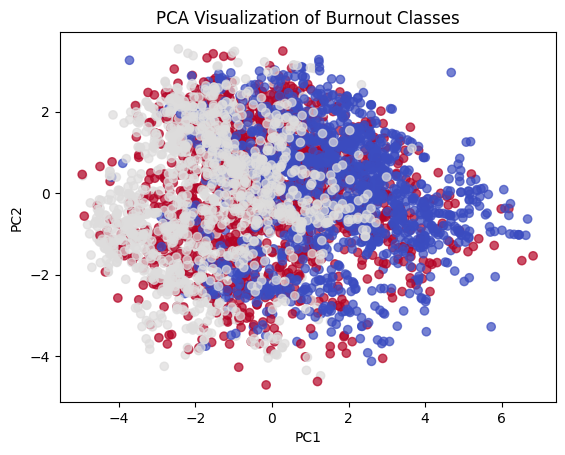

In [30]:
# --- PCA Example (for visualization) ---
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_resampled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_resampled, cmap='coolwarm', alpha=0.7)
plt.title("PCA Visualization of Burnout Classes")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [31]:
# -------------------------------------------------------------
# STEP 5 - Train-Test Split
# -------------------------------------------------------------
# Split dataset into training (80%) and testing (20%)
# Use stratify=y_resampled to maintain class balance
# Keep random_state fixed for reproducibility

from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

print(" Dataset split successfully!")
print("Training set shape:", X_train_final.shape)
print("Testing set shape:", X_test_final.shape)

# Optional: Verify class distribution in each set
print("\nTraining set class counts:\n", y_train_final.value_counts())
print("\nTesting set class counts:\n", y_test_final.value_counts())


 Dataset split successfully!
Training set shape: (3660, 21)
Testing set shape: (915, 21)

Training set class counts:
 burnout_level_encoded
0    1220
2    1220
1    1220
Name: count, dtype: int64

Testing set class counts:
 burnout_level_encoded
0    305
2    305
1    305
Name: count, dtype: int64


 Logistic Regression | Mean Accuracy: 0.6038 | Std Dev: 0.0175
 Random Forest | Mean Accuracy: 0.7833 | Std Dev: 0.0115

 ----- Logistic Regression Evaluation Results -----
Accuracy: 0.6032786885245902
Precision: 0.590137242933309
Recall: 0.6032786885245902
F1-Score: 0.5925369054696703

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71       305
           1       0.61      0.72      0.66       305
           2       0.46      0.35      0.40       305

    accuracy                           0.60       915
   macro avg       0.59      0.60      0.59       915
weighted avg       0.59      0.60      0.59       915



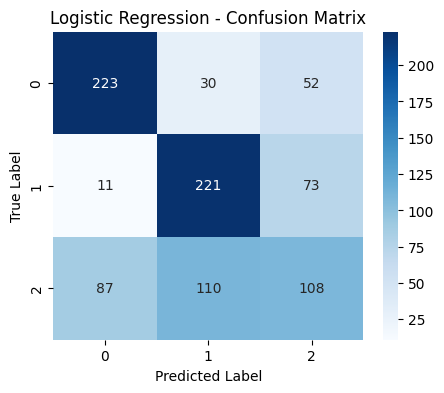


 ----- Random Forest Evaluation Results -----
Accuracy: 0.8065573770491803
Precision: 0.8052752686030089
Recall: 0.8065573770491803
F1-Score: 0.8050762283168562

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       305
           1       0.80      0.82      0.81       305
           2       0.78      0.71      0.74       305

    accuracy                           0.81       915
   macro avg       0.81      0.81      0.81       915
weighted avg       0.81      0.81      0.81       915



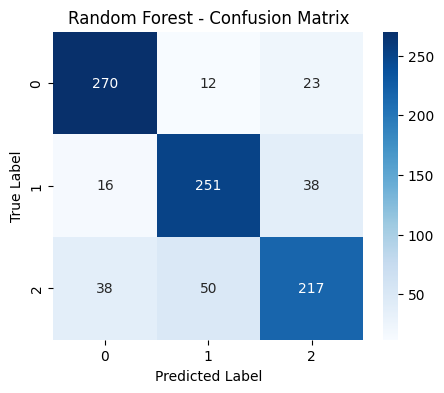

In [32]:
# STEP 6 - Model Building (Baseline Models)

# 1. Logistic Regression (simple baseline)
# 2. Random Forest Classifier (nonlinear, robust)

# -------------------------------------------------------------
# 6.1 - Import libraries
# -------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# -------------------------------------------------------------
# 6.2 - Define models
# -------------------------------------------------------------
log_reg = LogisticRegression(max_iter=500, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model
}

# -------------------------------------------------------------
# 6.3 - Train and evaluate models with 5-fold cross-validation
# -------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f" {name} | Mean Accuracy: {scores.mean():.4f} | Std Dev: {scores.std():.4f}")

# -------------------------------------------------------------
# 6.4 - Fit both models on the training data
# -------------------------------------------------------------
for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test_final)
    
    print(f"\n ----- {name} Evaluation Results -----")
    print("Accuracy:", accuracy_score(y_test_final, y_pred))
    print("Precision:", precision_score(y_test_final, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test_final, y_pred, average='weighted'))
    print("F1-Score:", f1_score(y_test_final, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test_final, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test_final, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


 Best Logistic Regression parameters:
{'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'saga'}
Best F1 Score: 0.5971865760665678

 Best Random Forest parameters:
{'bootstrap': False, 'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best F1 Score: 0.807782623262365

 ----- Logistic Regression (Tuned) Evaluation -----
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       305
           1       0.62      0.73      0.67       305
           2       0.47      0.36      0.41       305

    accuracy                           0.61       915
   macro avg       0.59      0.61      0.59       915
weighted avg       0.59      0.61      0.59       915



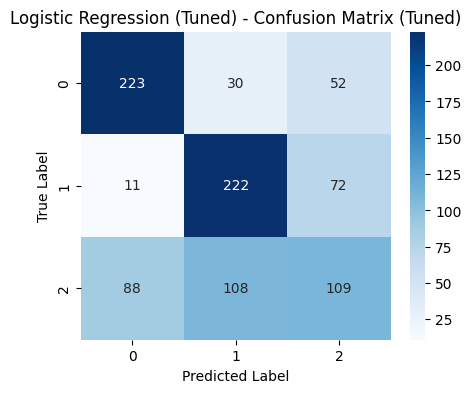


 ----- Random Forest (Tuned) Evaluation -----
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       305
           1       0.84      0.83      0.84       305
           2       0.78      0.76      0.77       305

    accuracy                           0.83       915
   macro avg       0.83      0.83      0.83       915
weighted avg       0.83      0.83      0.83       915



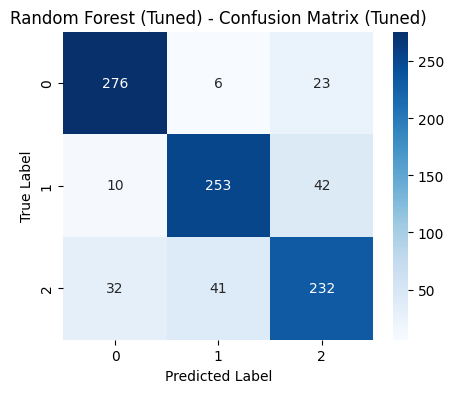

In [33]:
# -------------------------------------------------------------
# STEP 7 - Model Optimization (Improving Accuracy)
# -------------------------------------------------------------
from sklearn.model_selection import GridSearchCV

# -------------------------------------------------------------
# 7.1 - Hyperparameter tuning for Logistic Regression
# -------------------------------------------------------------
log_reg_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

log_reg_tuned = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_reg_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
log_reg_tuned.fit(X_train_final, y_train_final)

print(" Best Logistic Regression parameters:")
print(log_reg_tuned.best_params_)
print("Best F1 Score:", log_reg_tuned.best_score_)

# -------------------------------------------------------------
# 7.2 - Hyperparameter tuning for Random Forest
# -------------------------------------------------------------
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}
rf_tuned = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
rf_tuned.fit(X_train_final, y_train_final)

print("\n Best Random Forest parameters:")
print(rf_tuned.best_params_)
print("Best F1 Score:", rf_tuned.best_score_)

# -------------------------------------------------------------
# 7.3 - Evaluate tuned models
# -------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_tuned = {
    "Logistic Regression (Tuned)": log_reg_tuned.best_estimator_,
    "Random Forest (Tuned)": rf_tuned.best_estimator_
}

for name, model in models_tuned.items():
    y_pred = model.predict(X_test_final)
    print(f"\n ----- {name} Evaluation -----")
    print(classification_report(y_test_final, y_pred))

    cm = confusion_matrix(y_test_final, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix (Tuned)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


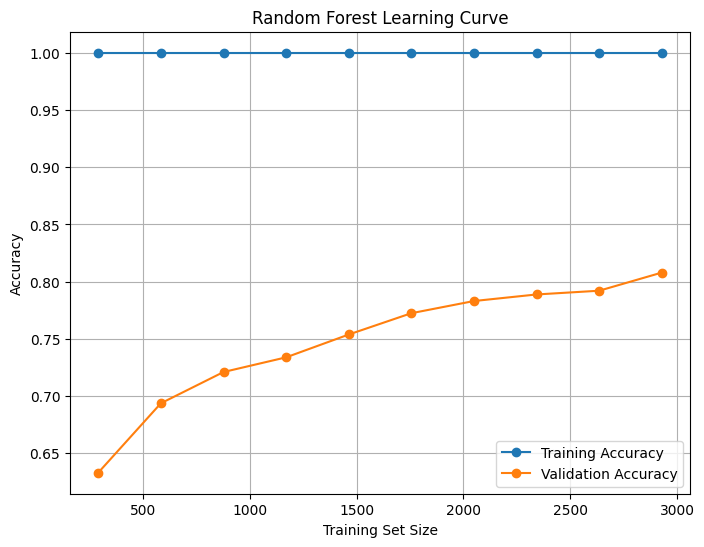

In [34]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    rf_tuned.best_estimator_, X_train_final, y_train_final,
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation Accuracy")
plt.title("Random Forest Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [35]:
# # -------------------------------------------------------------
# # STEP 8 - Feature Importance Visualization (Random Forest)
# # -------------------------------------------------------------
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # Extract feature importances from tuned Random Forest
# rf_best = rf_tuned.best_estimator_
# importances = rf_best.feature_importances_
# feature_names = X_train_final.columns

# # Sort by importance
# indices = np.argsort(importances)[::-1]
# top_n = 15  # show top 15 most important features
# top_features = [feature_names[i] for i in indices[:top_n]]
# top_importances = importances[indices[:top_n]]

# # Create dataframe
# feat_imp_df = pd.DataFrame({
#     'Feature': top_features,
#     'Importance': top_importances
# })

# # Plot
# plt.figure(figsize=(8,6))
# plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])
# plt.title('Top 15 Most Important Features for Burnout Prediction')
# plt.xlabel('Feature Importance Score')
# plt.ylabel('Feature Name')
# plt.grid(axis='x')
# plt.show()

# # Print ranked feature list
# print(" Top features influencing burnout classification:\n")
# print(feat_imp_df)


In [36]:
# -------------------------------------------------------------
# STEP 9 - Model Saving & Deployment Preparation
# -------------------------------------------------------------
import joblib
import os

# Create a directory for saved models if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# -------------------------------------------------------------
# 9.1 - Save the best performing model (Random Forest tuned)
# -------------------------------------------------------------
model_path = "saved_models/random_forest_burnout_model.pkl"
joblib.dump(rf_tuned.best_estimator_, model_path)
print(f" Model saved successfully at: {model_path}")

# -------------------------------------------------------------
# 9.2 - Save any encoders or preprocessors (if used)
# -------------------------------------------------------------
# Example: If you had a label encoder for target variable
# joblib.dump(label_encoder, "saved_models/label_encoder.pkl")

# Example: If you used a scaler (StandardScaler/MinMaxScaler)
# joblib.dump(scaler, "saved_models/scaler.pkl")

print(" All preprocessing components (if any) saved successfully.")

# -------------------------------------------------------------
# 9.3 - Reload the model (to verify it works)
# -------------------------------------------------------------
loaded_model = joblib.load(model_path)
print(" Model reloaded successfully!")

# Test the reloaded model on one sample
sample_prediction = loaded_model.predict(X_test_final.iloc[[0]])
print(f" Sample prediction (row 0): {sample_prediction[0]}")

# -------------------------------------------------------------
# 9.4 - Optional: Wrap into a prediction function
# -------------------------------------------------------------
def predict_burnout_level(input_data):
    """
    Takes a pandas DataFrame or single-row data and returns the burnout level.
    Example input: same structure as training features
    """
    return loaded_model.predict(input_data)

# Test the function
print("Predicted burnout level for test[0]:", predict_burnout_level(X_test_final.iloc[[0]])[0])


 Model saved successfully at: saved_models/random_forest_burnout_model.pkl
 All preprocessing components (if any) saved successfully.
 Model reloaded successfully!
 Sample prediction (row 0): 2
Predicted burnout level for test[0]: 2


In [37]:
# Example: If you used a scaler (StandardScaler/MinMaxScaler)
joblib.dump(scaler, "saved_models/scaler.pkl")

['saved_models/scaler.pkl']